Generating 50000 samples for each dimension...
  Dimension 1: Mean=0.5000, Std Dev=0.2887
  Dimension 2: Mean=0.6667, Std Dev=0.2357
  Dimension 3: Mean=0.7500, Std Dev=0.1936
  Dimension 5: Mean=0.8333, Std Dev=0.1409
  Dimension 10: Mean=0.9091, Std Dev=0.0830
  Dimension 25: Mean=0.9615, Std Dev=0.0370
  Dimension 50: Mean=0.9804, Std Dev=0.0192
  Dimension 100: Mean=0.9901, Std Dev=0.0098
  Dimension 500: Mean=0.9980, Std Dev=0.0020


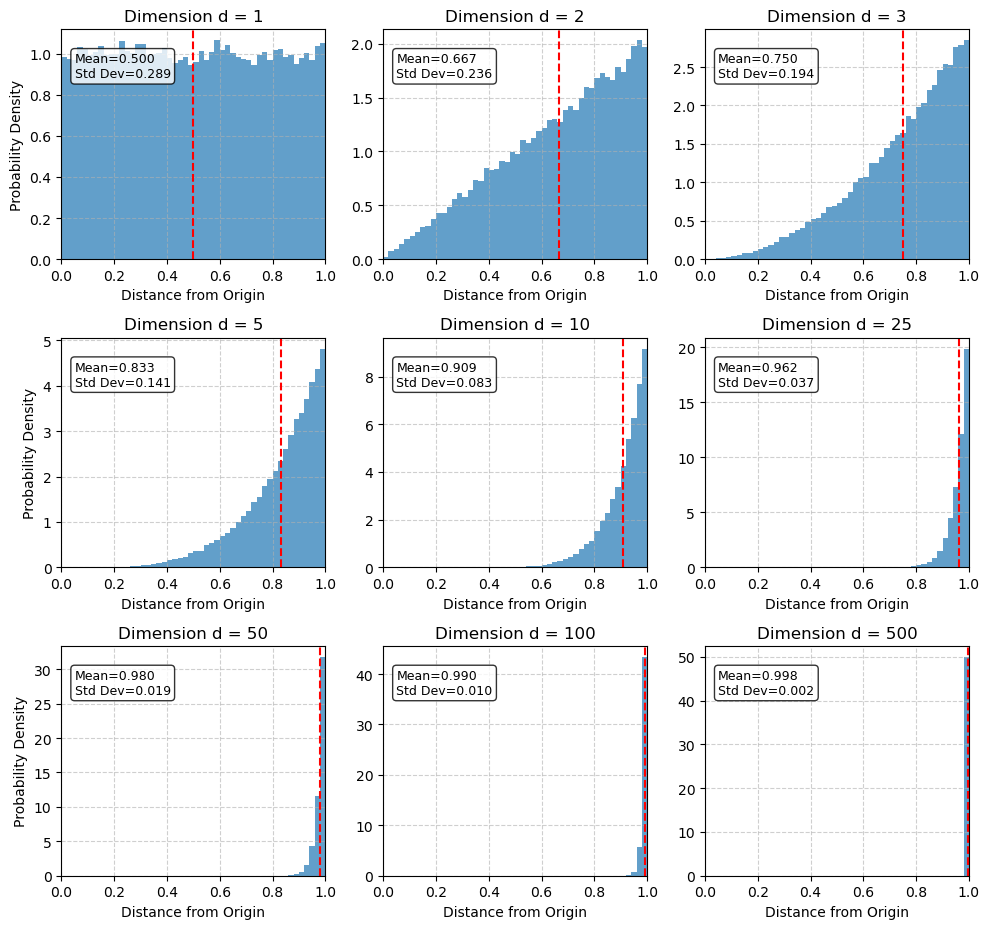


Done.


In [5]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import math

# --- Configuration ---
# Number of sample points for each dimension
num_samples = 50000

# Dimensions to test (9 dimensions for a 3x3 grid)
dimensions = [1, 2, 3, 5, 10, 25, 50, 100, 500]

# Number of bins for the histograms
num_bins = 50

# --- Simulation and Plotting ---

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

print(f"Generating {num_samples} samples for each dimension...")

for i, d in enumerate(dimensions):
    ax = axes[i] # Select the current subplot

    # --- Efficient Sampling of Distances ---
    # A key insight: If a point X is chosen uniformly from the *volume*
    # of a d-dimensional unit ball, its distance from the origin ||X||
    # has the probability distribution of U^(1/d), where U is a uniform
    # random variable in [0, 1].
    # This avoids generating d-dimensional vectors explicitly.

    # Generate uniform random numbers in [0, 1]
    uniform_samples = np.random.rand(num_samples)

    # Calculate distances from the origin
    distances = uniform_samples**(1/d)

    # --- Plotting the Histogram ---
    ax.hist(distances, bins=num_bins, range=(0, 1), density=True, alpha=0.7, label=f'd={d}')

    # --- Calculate Theoretical Mean and Std Dev (Optional but informative) ---
    # Mean distance: E[R] = E[U^(1/d)] = integral(r * pdf(r) dr) from 0 to 1
    # pdf(r) = d * r^(d-1) for r in [0, 1]
    # E[R] = integral(r * d * r^(d-1) dr) = d * integral(r^d dr) = d * [r^(d+1)/(d+1)] from 0 to 1 = d / (d+1)
    mean_dist = d / (d + 1)

    # E[R^2] = E[(U^(1/d))^2] = E[U^(2/d)] = integral(r^2 * pdf(r) dr)
    # E[R^2] = integral(r^2 * d * r^(d-1) dr) = d * integral(r^(d+1) dr) = d * [r^(d+2)/(d+2)] from 0 to 1 = d / (d+2)
    # Var(R) = E[R^2] - (E[R])^2 = d / (d+2) - (d / (d+1))^2
    # Std Dev(R) = sqrt(Var(R))
    variance = (d / (d + 2)) - (mean_dist**2)
    std_dev = np.sqrt(variance)

    # Add title and labels
    ax.set_title(f'Dimension d = {d}')
    ax.set_xlabel('Distance from Origin')
    if i % 3 == 0: # Add y-label only to the first column
      ax.set_ylabel('Probability Density')
    ax.set_xlim(0, 1) # Ensure x-axis is consistent
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add text for mean and std dev
    ax.axvline(mean_dist, color='r', linestyle='dashed', linewidth=1.5, label=f'Mean ≈ {mean_dist:.3f}')
    ax.text(0.05, 0.9, f'Mean={mean_dist:.3f}\nStd Dev={std_dev:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    print(f"  Dimension {d}: Mean={mean_dist:.4f}, Std Dev={std_dev:.4f}")


# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Add a bit of space for the main title

# # Add a main title to the figure
# fig.suptitle('Concentration of Distances in a Unit Hypersphere', fontsize=16)

# Show the plot
plt.show()

print("\nDone.")

Generating 50000 samples uniformly from the unit hypercube [-1, 1]^d for each dimension...
  Dimension 1: Sample Mean dist=0.4987, Sample Std Dev dist=0.2893 (Expected SQ dist=0.3333)
  Dimension 2: Sample Mean dist=0.7645, Sample Std Dev dist=0.2854 (Expected SQ dist=0.6667)
  Dimension 3: Sample Mean dist=0.9612, Sample Std Dev dist=0.2782 (Expected SQ dist=1.0000)
  Dimension 5: Sample Mean dist=1.2622, Sample Std Dev dist=0.2710 (Expected SQ dist=1.6667)
  Dimension 10: Sample Mean dist=1.8074, Sample Std Dev dist=0.2636 (Expected SQ dist=3.3333)
  Dimension 25: Sample Mean dist=2.8740, Sample Std Dev dist=0.2605 (Expected SQ dist=8.3333)
  Dimension 50: Sample Mean dist=4.0748, Sample Std Dev dist=0.2596 (Expected SQ dist=16.6667)
  Dimension 100: Sample Mean dist=5.7683, Sample Std Dev dist=0.2583 (Expected SQ dist=33.3333)
  Dimension 200: Sample Mean dist=8.1619, Sample Std Dev dist=0.2590 (Expected SQ dist=66.6667)


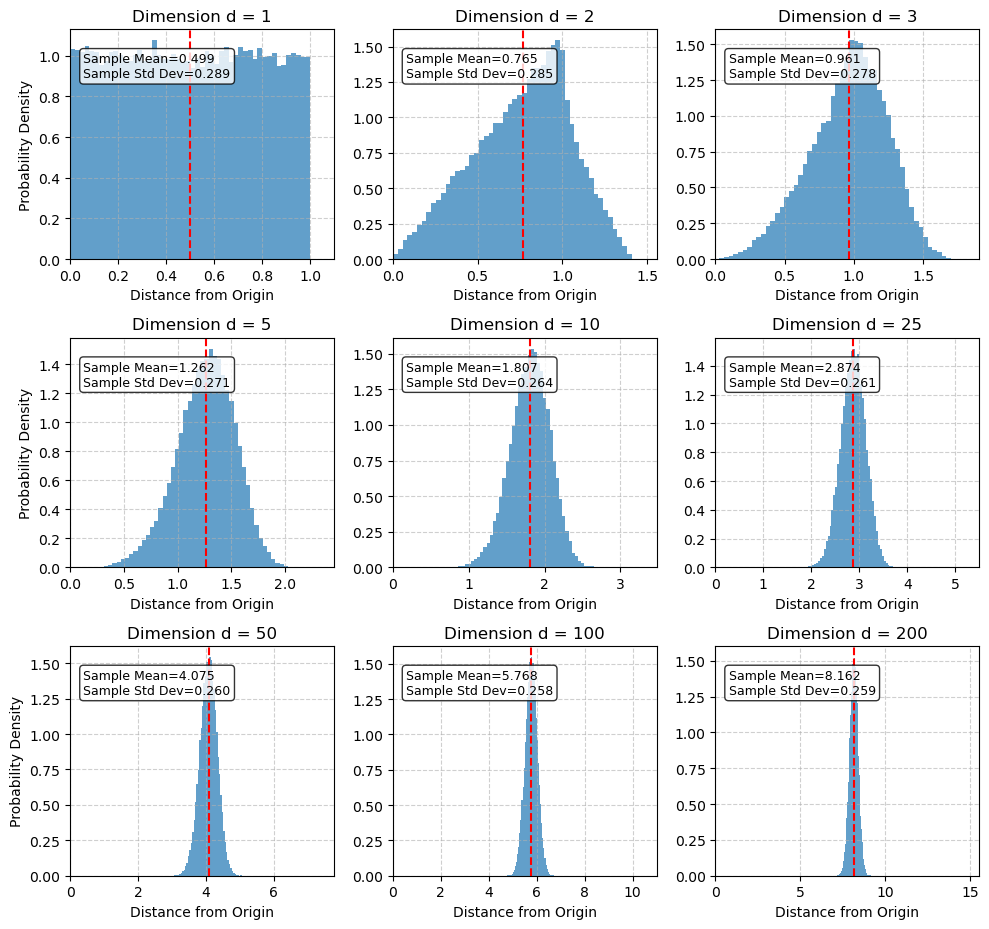


Done.


In [6]:
# --- Configuration ---
# Number of sample points for each dimension
num_samples = 50000

# Dimensions to test (9 dimensions for a 3x3 grid)
# Let's use slightly lower dimensions initially as distances grow with sqrt(d)
dimensions = [1, 2, 3, 5, 10, 25, 50, 100, 200] # Adjusted dimensions

# Number of bins for the histograms
num_bins = 50

# Define the hypercube limits (e.g., [-1, 1]^d)
cube_min = -1
cube_max = 1

# --- Simulation and Plotting ---

# Create a 3x3 subplot grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

print(f"Generating {num_samples} samples uniformly from the unit hypercube [{cube_min}, {cube_max}]^d for each dimension...")

for i, d in enumerate(dimensions):
    ax = axes[i] # Select the current subplot

    # --- Sampling Points Uniformly from the Hypercube ---
    # Each point X = (X_1, ..., X_d) has coordinates X_i sampled independently
    # from a Uniform(cube_min, cube_max) distribution.
    points = np.random.uniform(low=cube_min, high=cube_max, size=(num_samples, d))

    # --- Calculate Euclidean Distance from the Origin ---
    # Distance ||X|| = sqrt(X_1^2 + X_2^2 + ... + X_d^2)
    # Calculate squared distances first for efficiency
    squared_distances = np.sum(points**2, axis=1)
    distances = np.sqrt(squared_distances)

    # --- Calculate Sample Mean and Standard Deviation ---
    # Theoretical mean of squared distance E[||X||^2] = d * E[X_i^2]
    # For U[-1, 1], E[X_i^2] = 1/3. So E[||X||^2] = d/3.
    # The mean distance E[||X||] is approx sqrt(d/3), but we'll use the sample mean.
    mean_dist = np.mean(distances)
    std_dev = np.std(distances)
    # Theoretical standard deviation is harder to calculate directly, so we use sample std dev.

    # --- Plotting the Histogram ---
    # Note: The range of distances now increases with dimension d (max distance = sqrt(d))
    ax.hist(distances, bins=num_bins, density=True, alpha=0.7, label=f'd={d}')

    # Add title and labels
    ax.set_title(f'Dimension d = {d}')
    ax.set_xlabel('Distance from Origin')
    if i % 3 == 0: # Add y-label only to the first column
        ax.set_ylabel('Probability Density')

    # Set x-axis limits - increases with dimension
    # Max possible distance is sqrt(d * cube_max^2) = sqrt(d) for [-1, 1] cube
    max_possible_dist = math.sqrt(d * (cube_max**2))
    ax.set_xlim(0, max_possible_dist * 1.1) # Set limit slightly beyond max possible
    ax.grid(True, linestyle='--', alpha=0.6)

    # Add text for SAMPLE mean and std dev
    ax.axvline(mean_dist, color='r', linestyle='dashed', linewidth=1.5, label=f'Sample Mean ≈ {mean_dist:.3f}')
    ax.text(0.05, 0.9, f'Sample Mean={mean_dist:.3f}\nSample Std Dev={std_dev:.3f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

    # Expected squared distance (for reference)
    expected_sq_dist = d / 3.0
    print(f"  Dimension {d}: Sample Mean dist={mean_dist:.4f}, Sample Std Dev dist={std_dev:.4f} (Expected SQ dist={expected_sq_dist:.4f})")


# Adjust layout to prevent overlapping titles/labels
plt.tight_layout(rect=[0, 0.03, 1, 0.97]) # Add a bit of space for the main title

# # Add a main title to the figure
# fig.suptitle(f'Distribution of Distances from Origin within Unit Hypercube [{cube_min}, {cube_max}]^d', fontsize=16)

# Show the plot
plt.show()

print("\nDone.")